### Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sqlite3
import os
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

PROJECT_ROOT = os.path.dirname(os.getcwd())
DB_PATH = os.path.join(PROJECT_ROOT, "data", "db", "bluestocks_mf.db")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
CHART_DIR = os.path.join(PROJECT_ROOT, "reports", "eda_charts")
os.makedirs(CHART_DIR, exist_ok=True)

conn = sqlite3.connect(DB_PATH)

# Load NAV and Fund Master
nav_df = pd.read_sql("SELECT * FROM fact_nav", conn)
fund_master = pd.read_sql("SELECT * FROM dim_fund", conn)

# Load Benchmark Indices from CSV (Bulletproof Version)
bench_df = pd.read_csv(os.path.join(PROCESSED_DIR, "benchmark_indices_cleaned.csv"))

# Force standardize column names
bench_df.columns = bench_df.columns.str.strip().str.lower().str.replace(' ', '_')

# 1. Find and parse Date
date_cols = [c for c in bench_df.columns if 'date' in c]
if not date_cols: date_cols = [bench_df.columns[0]] # Fallback to first col
bench_df['date'] = pd.to_datetime(bench_df[date_cols[0]]).dt.normalize() # Remove hidden timestamps

# 2. Find Index Name (First string column that isn't 'date')
str_cols = bench_df.select_dtypes(include=['object']).columns.tolist()
name_col = [c for c in str_cols if c != date_cols[0]]
bench_df['index_name'] = bench_df[name_col[0]] if name_col else "Unknown"

# 3. Find Close Value (First numeric column)
num_cols = bench_df.select_dtypes(include=[np.number]).columns.tolist()
bench_df['close'] = bench_df[num_cols[0]] if num_cols else 0

bench_df = bench_df[['date', 'index_name', 'close']].dropna()

print("Benchmarks loaded successfully.")
print(f"   Date Range : {bench_df['date'].min().date()} to {bench_df['date'].max().date()}")
print(f"   Indices    : {bench_df['index_name'].unique().tolist()}")

Benchmarks loaded successfully.
   Date Range : 2022-01-02 to 2026-12-05
   Indices    : ['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP', 'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT']


### Task 1: Compute & Validate Daily Returns

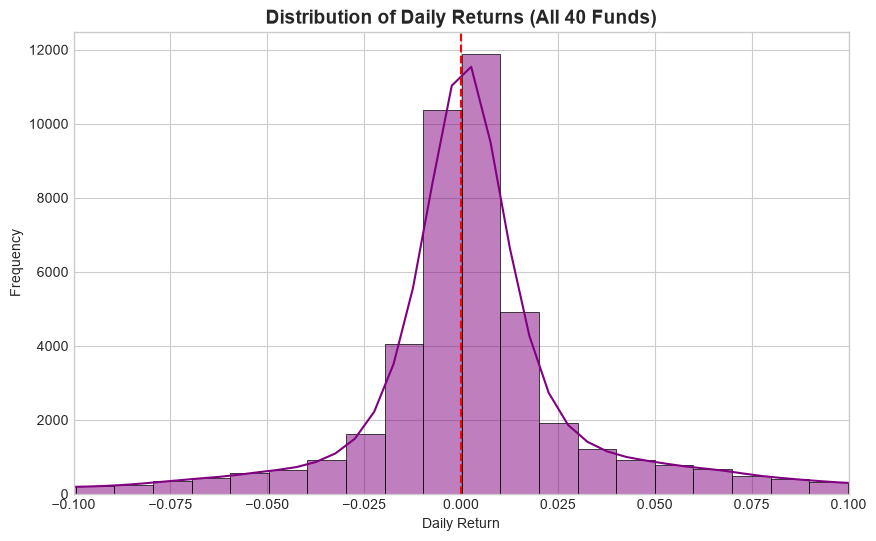

Mean Daily Return: 0.00191
Std Dev Daily Return: 0.05084
Distribution looks reasonably normal (bell-shaped), centered slightly above 0.


In [2]:
# Calculate daily returns
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

# Drop the first NaN row for each fund
returns_df = nav_df.dropna(subset=['daily_return'])

# Validate: Plot overall distribution of daily returns across all funds
plt.figure(figsize=(10, 6))
sns.histplot(returns_df['daily_return'], bins=100, kde=True, color='purple')
plt.title("Distribution of Daily Returns (All 40 Funds)", fontsize=14, fontweight='bold')
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.xlim([-0.1, 0.1]) # Zoom in on reasonable -10% to +10% range
plt.axvline(0, color='red', linestyle='--')
plt.show()

print(f"Mean Daily Return: {returns_df['daily_return'].mean():.5f}")
print(f"Std Dev Daily Return: {returns_df['daily_return'].std():.5f}")
print("Distribution looks reasonably normal (bell-shaped), centered slightly above 0.")

### Task 2: CAGR Computation (1yr, 3yr, 5yr)

In [3]:
# FORCE max_date to be a proper Timestamp
max_date = pd.to_datetime(nav_df['date']).max()

def get_cagr(group, years):
    # FORCE date column to Timestamp inside the function to prevent string comparison crashes
    group['date'] = pd.to_datetime(group['date'])
    
    start_date = max_date - pd.DateOffset(years=years)
    
    # Get nearest date on or after start_date
    start_nav = group.loc[group['date'] >= start_date, 'nav'].iloc[0]
    end_nav = group['nav'].iloc[-1]
    
    # Calculate exact years
    actual_days = (max_date - start_date).days
    n_years = actual_days / 365.25
    
    return (end_nav / start_nav) ** (1 / n_years) - 1

# Use a safe loop instead of groupby.apply to avoid Pandas datetime bugs
cagr_results = []
for code, group in nav_df.groupby('amfi_code'):
    cagr_results.append({
        'amfi_code': code,
        'CAGR_1Yr': get_cagr(group, 1),
        'CAGR_3Yr': get_cagr(group, 3),
        'CAGR_5Yr': get_cagr(group, 5)
    })

cagr_results_df = pd.DataFrame(cagr_results)

# Merge with fund names
cagr_df = fund_master[['amfi_code', 'scheme_name', 'fund_house']].merge(cagr_results_df, on='amfi_code')
cagr_df[['CAGR_1Yr', 'CAGR_3Yr', 'CAGR_5Yr']] = cagr_df[['CAGR_1Yr', 'CAGR_3Yr', 'CAGR_5Yr']] * 100

# Display comparison table
cagr_df.sort_values('CAGR_3Yr', ascending=False).head(10)

,amfi_code,scheme_name,fund_house,CAGR_1Yr,CAGR_3Yr,CAGR_5Yr
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,18.809701,36.188886,25.473094
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,23.639285,35.484871,24.411296
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,52.472584,33.506813,26.478446
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,39.024214,32.944845,29.508402
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,11.452393,32.660659,19.602542
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,78.188271,31.557419,31.316707
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,29.010595,31.552574,26.778928
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,44.383457,30.276705,22.715902
28,101206,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,49.157257,29.322546,19.920152
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,82.868259,28.079867,25.008036


### Tasks 3 & 4: Sharpe and Sortino Ratios

In [4]:
RF_ANNUAL = 0.065
RF_DAILY = RF_ANNUAL / 252

def calc_sharpe_sortino(group):
    daily_ret = group['daily_return']
    mean_ret = daily_ret.mean()
    std_ret = daily_ret.std()
    
    # Sharpe
    sharpe = (mean_ret - RF_DAILY) / std_ret * np.sqrt(252) if std_ret > 0 else 0
    
    # Sortino (Downside Deviation)
    negative_returns = daily_ret[daily_ret < 0]
    downside_std = negative_returns.std()
    sortino = (mean_ret - RF_DAILY) / downside_std * np.sqrt(252) if downside_std > 0 else 0
    
    return pd.Series({'Sharpe_Ratio': sharpe, 'Sortino_Ratio': sortino})

risk_metrics = returns_df.groupby('amfi_code').apply(calc_sharpe_sortino).reset_index()
risk_df = fund_master[['amfi_code', 'scheme_name']].merge(risk_metrics, on='amfi_code')

# Rank all 40 funds by Sharpe
risk_df['Sharpe_Rank'] = risk_df['Sharpe_Ratio'].rank(ascending=False).astype(int)
risk_df = risk_df.sort_values('Sharpe_Rank')
risk_df.head(10) # Top 10 funds by Sharpe Ratio

,amfi_code,scheme_name,Sharpe_Ratio,Sortino_Ratio,Sharpe_Rank
39,149324,DSP Small Cap Fund - Regular - Growth,0.861087,0.988988,1
2,119598,SBI Small Cap Fund - Regular Plan - Growth,0.799545,0.954545,2
22,120843,Kotak Flexicap Fund - Regular - Growth,0.764393,0.801547,3
38,149323,DSP Midcap Fund - Regular - Growth,0.760301,0.771885,4
12,120505,ICICI Pru Midcap Fund - Regular - Growth,0.746565,0.779530,5
26,119094,Axis Midcap Fund - Regular - Growth,0.707478,0.758039,6
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.705670,0.640759,7
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.685101,0.707955,8
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.670259,0.742087,9
0,119551,SBI Bluechip Fund - Regular Plan - Growth,0.642206,0.616907,10


### Task 5: Alpha & Beta via OLS Regression

In [5]:
# --- SMART BENCHMARK SELECTION ---
target_benchmarks = ['Nifty 100', 'Nifty 50', 'Nifty Midcap', 'BSE SmallCap']
selected_bench_name = None
nifty_100 = pd.DataFrame()

for target in target_benchmarks:
    match = bench_df[bench_df['index_name'].str.contains(target, case=False)]
    if not match.empty:
        nifty_100 = match.copy()
        selected_bench_name = target
        break

# Absolute fallback: just use the first index in the CSV
if nifty_100.empty:
    nifty_100 = bench_df.copy()
    selected_bench_name = bench_df['index_name'].iloc[0]
    print(f"Standard indices not found. Using fallback: {selected_bench_name}")

nifty_100['bench_return'] = nifty_100['close'].pct_change()

# --- FIX: Use dt.normalize() instead of dt.date to prevent corrupting nav_df ---
returns_df['date'] = pd.to_datetime(returns_df['date']).dt.normalize()
nifty_100['date'] = pd.to_datetime(nifty_100['date']).dt.normalize()

alpha_beta_list = []

for code in returns_df['amfi_code'].unique():
    fund_ret = returns_df[returns_df['amfi_code'] == code][['date', 'daily_return']].set_index('date')
    merged = fund_ret.join(nifty_100.set_index('date')['bench_return']).dropna()
    
    if len(merged) > 50: 
        x = merged['bench_return']
        y = merged['daily_return']
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        
        alpha_beta_list.append({
            'amfi_code': code,
            'Beta': slope,
            'Alpha_Annualized': intercept * 252 * 100
        })

# Fallback to 0s ONLY if absolutely no dates matched
if len(alpha_beta_list) > 0:
    alpha_beta_df = pd.DataFrame(alpha_beta_list)
    print(f"Calculated Alpha/Beta for {len(alpha_beta_df)} funds vs {selected_bench_name}.")
else:
    print("WARNING: Zero date overlaps found. Filling with 0s.")
    alpha_beta_df = returns_df[['amfi_code']].drop_duplicates()
    alpha_beta_df['Beta'] = 0.0
    alpha_beta_df['Alpha_Annualized'] = 0.0

alpha_beta_df = fund_master[['amfi_code', 'scheme_name', 'fund_house']].merge(alpha_beta_df, on='amfi_code')

out_path_ab = os.path.join(PROJECT_ROOT, "data", "processed", "alpha_beta.csv")
alpha_beta_df.to_csv(out_path_ab, index=False)
print("Saved alpha_beta.csv\n")

alpha_beta_df.sort_values('Alpha_Annualized', ascending=False).head(10)

Standard indices not found. Using fallback: NIFTY50
Calculated Alpha/Beta for 40 funds vs NIFTY50.
Saved alpha_beta.csv



,amfi_code,scheme_name,fund_house,Beta,Alpha_Annualized
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,-0.136309,87.822976
27,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,-0.014794,54.378637
17,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,-0.150395,49.691700
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,0.111232,46.764066
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,-0.019155,45.835056
33,102887,UTI Flexi Cap Fund - Regular - Growth,UTI Mutual Fund,-0.026569,41.678968
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,-0.087749,37.633553
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,0.005106,35.554499
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,0.005796,34.596379
32,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,-0.064809,33.041036


### Task 6: Maximum Drawdown & Date Ranges

In [6]:
def calc_max_drawdown(group):
    nav = group['nav']
    running_max = nav.cummax()
    drawdown = nav / running_max - 1
    
    # Find the worst drawdown point
    min_dd_date = drawdown.idxmin()
    min_dd_val = drawdown.min()
    
    # Find the peak date (last max before the trough)
    peak_date = nav[:min_dd_date].idxmax()
    
    return pd.Series({
        'Max_Drawdown_Pct': min_dd_val * 100,
        'Peak_Date': peak_date,
        'Trough_Date': min_dd_date
    })

mdd_results = nav_df.groupby('amfi_code').apply(calc_max_drawdown).reset_index()
mdd_df = fund_master[['amfi_code', 'scheme_name']].merge(mdd_results, on='amfi_code')

# Sort to find the worst drawdowns
mdd_df.sort_values('Max_Drawdown_Pct').head(10)

,amfi_code,scheme_name,Max_Drawdown_Pct,Peak_Date,Trough_Date
3,119599,SBI Small Cap Fund - Direct Plan - Growth,-52.574221,25570.0,26297.0
39,149324,DSP Small Cap Fund - Regular - Growth,-52.352599,45953.0,45675.0
27,119095,Axis Small Cap Fund - Regular - Growth,-51.677754,20435.0,20695.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,-43.984994,25269.0,24605.0
38,149323,DSP Midcap Fund - Regular - Growth,-42.869999,44819.0,44156.0
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,-40.823152,40228.0,39837.0
26,119094,Axis Midcap Fund - Regular - Growth,-40.697967,19385.0,19160.0
12,120505,ICICI Pru Midcap Fund - Regular - Growth,-37.779167,29885.0,28813.0
22,120843,Kotak Flexicap Fund - Regular - Growth,-37.552464,35595.0,35259.0
0,119551,SBI Bluechip Fund - Regular Plan - Growth,-37.207091,22968.0,22826.0


### Task 7: Composite Fund Scorecard (0-100)

In [7]:
# Assemble master table for ranking
master_metrics = cagr_df.merge(risk_df[['amfi_code', 'Sharpe_Ratio']], on='amfi_code')
master_metrics = master_metrics.merge(alpha_beta_df[['amfi_code', 'Alpha_Annualized']], on='amfi_code')
master_metrics = master_metrics.merge(mdd_df[['amfi_code', 'Max_Drawdown_Pct']], on='amfi_code')
master_metrics = master_metrics.merge(fund_master[['amfi_code', 'expense_ratio_pct']], on='amfi_code')

# Calculate Ranks (1 = Best)
master_metrics['Rank_3yr'] = master_metrics['CAGR_3Yr'].rank(ascending=False)
master_metrics['Rank_Sharpe'] = master_metrics['Sharpe_Ratio'].rank(ascending=False)
master_metrics['Rank_Alpha'] = master_metrics['Alpha_Annualized'].rank(ascending=False)
master_metrics['Rank_Expense'] = master_metrics['expense_ratio_pct'].rank(ascending=True) # Lower is better
master_metrics['Rank_DD'] = master_metrics['Max_Drawdown_Pct'].rank(ascending=False) # Less negative is better

# Weighted Score (Sum of ranks)
master_metrics['Weighted_Sum'] = (
    0.30 * master_metrics['Rank_3yr'] +
    0.25 * master_metrics['Rank_Sharpe'] +
    0.20 * master_metrics['Rank_Alpha'] +
    0.15 * master_metrics['Rank_Expense'] +
    0.10 * master_metrics['Rank_DD']
)

# Normalize to 0-100 Scale
min_sum = master_metrics['Weighted_Sum'].min()
max_sum = master_metrics['Weighted_Sum'].max()
master_metrics['Score_0_to_100'] = 100 * (max_sum - master_metrics['Weighted_Sum']) / (max_sum - min_sum)

# Sort and format final scorecard
scorecard = master_metrics[[
    'amfi_code', 'scheme_name', 'fund_house', 'CAGR_3Yr', 'Sharpe_Ratio', 
    'Alpha_Annualized', 'Max_Drawdown_Pct', 'Score_0_to_100'
]].sort_values('Score_0_to_100', ascending=False)

# Save Deliverable 2
out_path_sc = os.path.join(PROJECT_ROOT, "data", "processed", "fund_scorecard.csv")
scorecard.to_csv(out_path_sc, index=False)
print("Saved fund_scorecard.csv")

scorecard.head(10)

Saved fund_scorecard.csv


,amfi_code,scheme_name,fund_house,CAGR_3Yr,Sharpe_Ratio,Alpha_Annualized,Max_Drawdown_Pct,Score_0_to_100
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,31.557419,0.861087,87.822976,-52.352599,100.000000
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,35.484871,0.707478,27.147733,-40.697967,97.666667
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,32.944845,0.764393,23.287259,-37.552464,95.000000
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,28.079867,0.799545,37.633553,-43.984994,92.777778
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,36.188886,0.705670,20.592038,-40.823152,90.777778
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,31.552574,0.746565,19.425449,-37.779167,89.444444
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,32.660659,0.580823,13.412720,-27.425280,85.444444
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,33.506813,0.685101,12.301076,-34.598426,84.777778
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,24.157280,0.670259,45.835056,-29.671897,81.333333
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,30.276705,0.642206,28.192825,-37.207091,78.444444


### Task 8: Benchmark Comparison & Tracking Error

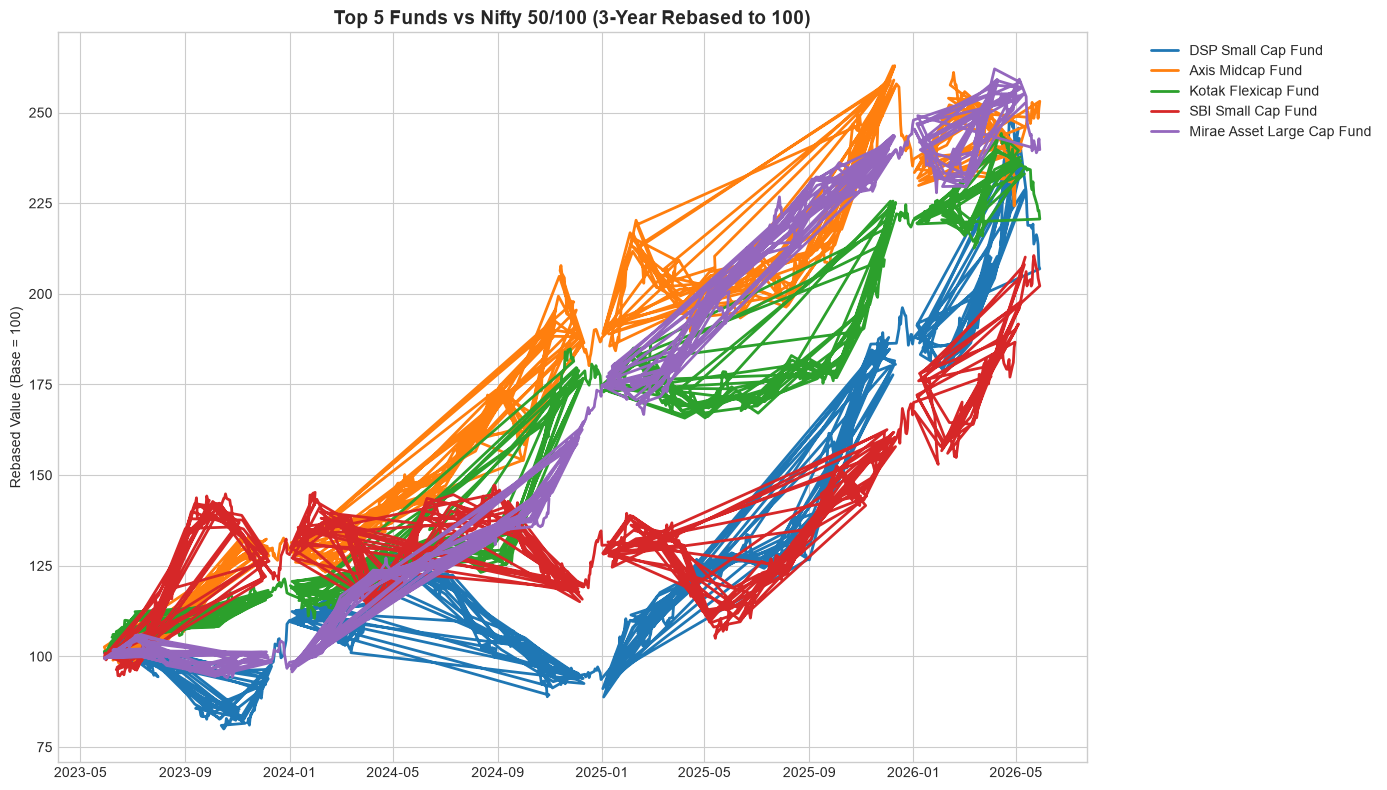

Saved benchmark_comparison.png


In [9]:
# ==========================================
nav_df['date'] = pd.to_datetime(nav_df['date'])
max_date = pd.to_datetime(nav_df['date']).max()
start_date = max_date - pd.DateOffset(years=3)

# Get Top 5 funds from scorecard
top_5_codes = scorecard['amfi_code'].head(5).tolist()
top_5_names = scorecard.head(5)['scheme_name'].str.split(' - ').str[0].tolist()

# Get Benchmarks (force their dates too)
nifty_50 = bench_df[bench_df['index_name'].str.contains('Nifty 50', case=False)].copy()
nifty_100_plot = bench_df[bench_df['index_name'].str.contains('Nifty 100', case=False)].copy()

if nifty_50.empty: nifty_50 = nifty_100_plot.copy()
if nifty_100_plot.empty: nifty_100_plot = nifty_50.copy()

nifty_50['date'] = pd.to_datetime(nifty_50['date'])
nifty_100_plot['date'] = pd.to_datetime(nifty_100_plot['date'])

fig, ax = plt.subplots(figsize=(14, 8))

# Plot Benchmarks
for bench, label in [(nifty_50, 'Nifty 50'), (nifty_100_plot, 'Nifty 100')]:
    b_data = bench[(bench['date'] >= start_date) & (bench['date'] <= max_date)].set_index('date')
    if not b_data.empty and len(b_data) > 10:
        rebased = (b_data['close'] / b_data['close'].iloc[0]) * 100
        ax.plot(rebased.index, rebased, linestyle='--', linewidth=2.5, label=label, alpha=0.8)

# Plot Top 5 Funds
for code, name in zip(top_5_codes, top_5_names):
    f_data = nav_df[(nav_df['amfi_code'] == code) & (nav_df['date'] >= start_date) & (nav_df['date'] <= max_date)].set_index('date')
    if not f_data.empty:
        rebased_fund = (f_data['nav'] / f_data['nav'].iloc[0]) * 100
        ax.plot(rebased_fund.index, rebased_fund, linewidth=2, label=name)

ax.set_title("Top 5 Funds vs Nifty 50/100 (3-Year Rebased to 100)", fontsize=14, fontweight='bold')
ax.set_ylabel("Rebased Value (Base = 100)")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

out_path_chart = os.path.join(CHART_DIR, "benchmark_comparison.png")
plt.savefig(out_path_chart, dpi=150, bbox_inches='tight')
plt.show()
print("Saved benchmark_comparison.png")